## Installing dependencies

In [1]:
!pip install diffusers transformers accelerate scipy safetensors xformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 42.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.3/15.3 MB 58.4 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 906.4/906.4 MB 1.7 MB/s eta 0:00:00:00:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 38.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 35.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.8 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 28.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 12.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━

## Imports

In [543]:
import torch
from torchvision import transforms
from diffusers import StableDiffusionPipeline, EulerDiscreteScheduler, DDIMScheduler
from PIL import Image
# from transformers import CLIPModel, CLIPProcessor
from dataclasses import dataclass
import os
import numpy as np
import torch.nn.functional as F
from typing import List, Union, Optional, Dict, Any, Tuple
import gc
from enum import Enum
import tqdm

## Setting up cuda

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")

Using: cuda


In [4]:
# Print GPU info
!nvidia-smi

Wed Jan  8 02:05:44 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.35.03              Driver Version: 560.35.03      CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8             12W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

/usr/lib/python3.10/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


In [5]:
!export PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True

## Utils

In [6]:
def get_inputs(prompt, batch_size=1, num_inference_steps=20):
  generator = [torch.Generator(device).manual_seed(i) for i in range(batch_size)]
  prompts = [prompt for _ in range(batch_size)]

  return {"prompt": prompts, "generator": generator, "num_inference_steps": num_inference_steps}

def image_grid(imgs, rows=2, cols=2):
    w, h = imgs[0].size
    grid = Image.new('RGB', size=(cols*w, rows*h))

    for i, img in enumerate(imgs):
        grid.paste(img, box=(i%cols*w, i//cols*h))
    return grid

def image_to_tensor(image, device):
    image_tensor = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]) # normalize between -1 and 1
    ])(image)

    return image_tensor.unsqueeze(0).to(device, dtype=torch.float16) # unsqueeze(0) adds new dimension to tensor at index 0

def map_to_zero_one(tensor):
    tensor = (tensor.clamp(-1, 1) + 1) / 2.0 # map tensor from (-1, 1) to (0, 1)
    return tensor

def load_images_from_dir(imgs_path) -> list[Image.Image]:
    images = []
    for img in os.listdir(imgs_path):
        if img.endswith(('.jpeg', '.jpg', '.png')):
            images.append(Image.open(os.path.join(imgs_path, img)))
    return images

def print_pipe_info(pipe):
    print(pipe.__dict__)

def freeze_params(module):
    for param in module.parameters():
        param.requires_grad = False
    for name, submodule in module.named_children():
        if isinstance(submodule, torch.nn.Module):
            freeze_params(submodule)

def check_if_trainable_params(module, tp):
    for param_name, param in module.named_parameters():
        if param.requires_grad:
            tp = True
            # print(f"Parameter {param_name} is trainable!!!")
    for name, submodule in module.named_children():
        if isinstance(submodule, torch.nn.Module):
            check_if_trainable_params(submodule, tp)

def check_if_trainable_params_pipe(pipe):
    tp = False
    for submodule_name in pipe.components:
        submodule = pipe.components[submodule_name]
        if isinstance(submodule, torch.nn.Module):
            print(f"Checking in {submodule.__class__.__name__}...")
            check_if_trainable_params(submodule, tp)
    if not tp:
        print("No trainable parameters found in pipe :)")
    return tp

def check_if_trainable_params_clip(clip_model):
    tp = False
    check_if_trainable_params(clip_model, tp)
    if not tp:
        print("No trainable parameters found in clip :)")
    return tp

def freeze_params_pipe(pipe):
    for submodule_name in pipe.components:
        submodule = pipe.components[submodule_name]
        if isinstance(submodule, torch.nn.Module):
            freeze_params(submodule)

def assert_no_trainable_params_pipe(pipe):
    assert not check_if_trainable_params_pipe(pipe), "Pipe has trainable parameters."

def assert_no_trainable_params_clip(clip_model):
    assert not check_if_trainable_params_clip(clip_model), "Clip Model has trainable parameters."

def free(*vars):
    for var in vars:
        del var
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

def clear():
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

def peek_tensor(tensor):
    name = f'{tensor=}'.split('=')[0]
    print(f"[DEBUG] {name}: min={tensor.min().item()}, max={tensor.max().item()}, any_nan={torch.isnan(tensor).any()}")

## Getting reference images

In [7]:
using_colab = False

if using_colab:
    from google.colab import drive
    drive.mount('/content/drive')
    # IMGS_DIR = "/content/drive/MyDrive/ufrgs-cloud/etapa8/deep_learning/images/"
    IMGS_DIR = "/content/drive/MyDrive/images/"
else:
    IMGS_DIR = "../input/"

## Importing models

In [8]:
# Paper:
# SeedSelect employs Stable Diffusion v2.1 with a guidance scale of 7.5 and 7 denoising steps
# using EulerDiscreteScheduler (Karras et al. 2022)

# SD model
model_id = "stable-diffusion-v1-5/stable-diffusion-v1-5"
# "stable-diffusion-v1-5/stable-diffusion-v1-5"
# "runwayml/stable-diffusion-v1-5"
# "stable-diffusion-v1-5/v1-5-pruned-emaonly.safetensors"
# "stabilityai/stable-diffusion-2-1-base"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    variant="fp16",
    # scheduler=DDIMScheduler.from_pretrained(model_id, subfolder="scheduler")
)

# Use pruned model
# !wget https://huggingface.co/sd-legacy/stable-diffusion-v1-5/resolve/main/v1-5-pruned-emaonly.safetensors
# pipe = StableDiffusionPipeline.from_single_file(
#     "v1-5-pruned-emaonly.safetensors",
#     torch_dtype=torch.float16,
#     load_safety_checker=True,
#     variant="fp16"
# )

# Configuring pipe
pipe.to(device)
# Freezing model
pipe.vae.requires_grad_(False)
pipe.unet.requires_grad_(False)
pipe.text_encoder.requires_grad_(False)

# CLIP vision model
@dataclass
class Clip:
    model: torch.nn.Module
    processor: Any
clip_model = pipe.safety_checker.vision_model
clip_processor = pipe.feature_extractor
clip = Clip(model=clip_model, processor=clip_processor)
# Freezing model
clip.model.requires_grad_(False)

# clip_model = CLIPModel.from_pretrained("openai/clip-vit-large-patch14").to(device)
# clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-large-patch14")

print("Done loading models")

model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

safety_checker/config.json:   0%|          | 0.00/4.72k [00:00<?, ?B/s]

text_encoder/config.json:   0%|          | 0.00/617 [00:00<?, ?B/s]

tokenizer/special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

...

tokenizer/vocab.json:   0%|          | 0.00/1.06M [00:00<?, ?B/s]

diffusion_pytorch_model.fp16.safetensors:   0%|          | 0.00/167M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Done loading models


### Improve memory efficiency

In [9]:
pipe.enable_xformers_memory_efficient_attention()
pipe.enable_vae_slicing()
pipe.vae.enable_gradient_checkpointing()
# pipe.enable_sequential_cpu_offload()

In [10]:
device0 = torch.device("cuda:0")
device1 = torch.device("cuda:1")

## VAE

In [243]:
# VAE

@torch.no_grad
def encode_image_vae(pipe, image):
    vae = pipe.vae
    image_tensor = image_to_tensor(image, vae.device)
    image_latent = vae.encode(image_tensor).latent_dist.sample().to(vae.device) # samples from latent distribution
    image_latent *= pipe.vae.config.scaling_factor

    return image_latent

@torch.no_grad
def decode_vae(pipe, image_latent):
    image = pipe.vae.decode(image_latent / pipe.vae.config.scaling_factor).sample
    image = (image / 2 + 0.5).clamp(0, 1)
    return image

    return image

@torch.no_grad
def encode_image_list_vae(pipe, images):
    return [encode_image_vae(pipe, image).detach() for image in images] # .to(pipe.device)

## CLIP Vision

In [288]:
# CLIP

@torch.no_grad
def encode_image_clip(clip_model, clip_processor, image):
    inputs = clip_processor(images=image, return_tensors="pt").to(clip_model.device)
    # image_embeddings = clip_model.get_image_features(pixel_values=inputs["pixel_values"]).to(clip_model.device)
    image_embeddings = clip_model(**inputs).pooler_output
    image_embeddings = image_embeddings / image_embeddings.norm(dim=-1, keepdim=True) # normalize

    return image_embeddings

## Testing

### Reducing latent size

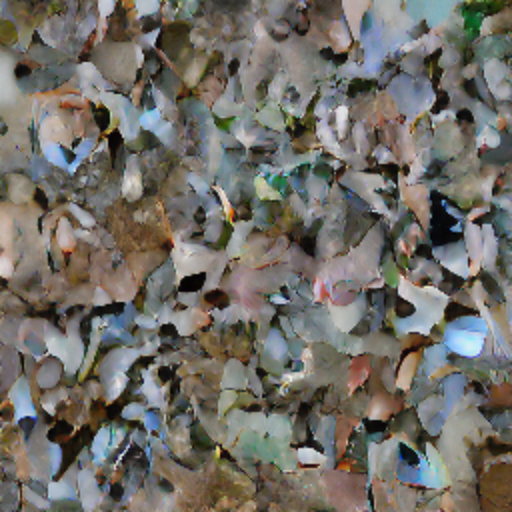

In [65]:
l = torch.randn((1, 4, 64, 64), dtype=torch.float16, device=device1)
l = F.interpolate(l, scale_factor=0.5, mode="bilinear", align_corners=False)
g = pipe.vae.decode(l / pipe.vae.config.scaling_factor).sample
g = (g / 2 + 0.5).clamp(0, 1)
g = F.interpolate(g, scale_factor=2.0, mode="bilinear", align_corners=False)
g = transforms.ToPILImage()(g.squeeze(0))

g

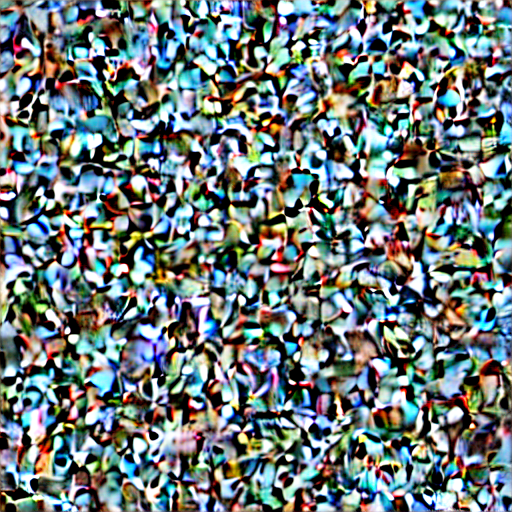

In [64]:
l = torch.randn((1, 4, 64, 64), dtype=torch.float16, device=device1, requires_grad=True)
# l = F.interpolate(l, scale_factor=0.5, mode="bilinear", align_corners=False)
g = pipe.vae.decode(l / pipe.vae.config.scaling_factor).sample
g = (g / 2 + 0.5).clamp(0, 1)
# g = F.interpolate(g, scale_factor=2.0, mode="bilinear", align_corners=False)
g = transforms.ToPILImage()(g.squeeze(0))

g

### Running pipe

  0%|          | 0/20 [00:00<?, ?it/s]

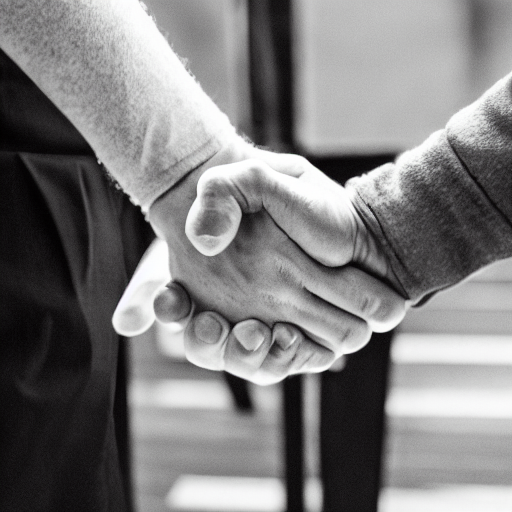

In [ ]:
image = pipe(
    prompt="two men shaking hands",
    num_inference_steps=20,
    guidance_scale=7.5,
    generator=torch.Generator(pipe.device).manual_seed(0)
    ).images[0]
image

### Smaller images

  0%|          | 0/200 [00:00<?, ?it/s]

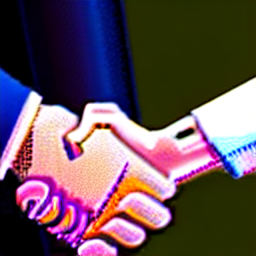

In [ ]:
pipe.unet.config.sample_size = 32
latent = torch.randn(1, pipe.unet.config.in_channels, pipe.unet.config.sample_size, pipe.unet.config.sample_size, device=pipe.device, generator=torch.Generator(device).manual_seed(0), dtype=pipe.dtype)
image = pipe(prompt="two men shaking hands", latents=latent, num_inference_steps=200, guidance_scale=6).images[0]
pipe.unet.config.sample_size = 64
image

### Using random gaussian as initial latent

In [ ]:
def generate_gaussian_latent(pipe, batch_size=1, size=(512, 512), generator=None, requires_grad=True, device="cuda", dtype=torch.float16):
    channels = pipe.unet.config.in_channels
    custom_latents = torch.randn(
        (batch_size, channels, size[0] // 8, size[1] // 8),
        device=device,
        dtype=dtype,
        generator=generator,
        requires_grad=requires_grad)
    return custom_latents

In [ ]:
generator = torch.Generator(device).manual_seed(0)
custom_latents = generate_gaussian_latent(pipe, generator=generator)
output_custom_latents = pipe(prompt, latents=custom_latents, num_inference_steps=NUM_INFERENCE_STEPS, guidance_scale=GUIDANCE_SCALE, generator=generator).images[0]
output_custom_latents

### Computing loss

  0%|          | 0/7 [00:00<?, ?it/s]

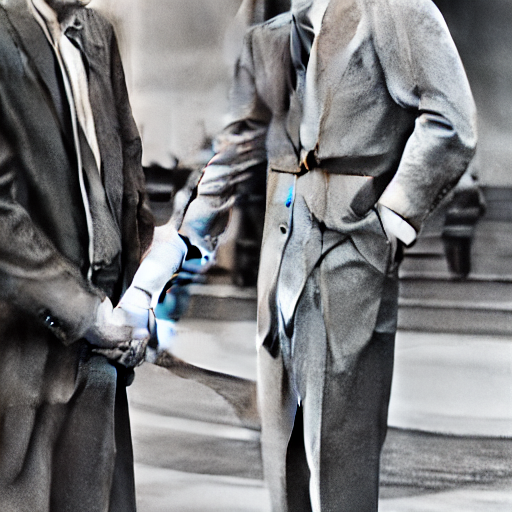

In [218]:
pipe = pipe.to(device0)
prompt = "two men shaking hands"
generator = torch.Generator(device).manual_seed(0)
test_img = pipe(prompt, num_inference_steps=7, guidance_scale=7.5, generator=generator).images[0]
test_img

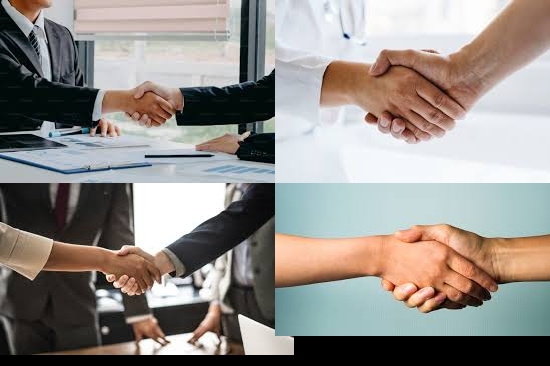

In [219]:
imgs_type = "hs"
reference_images = load_images_from_dir(os.path.join(IMGS_DIR, imgs_type))
image_grid(reference_images)

In [248]:
loss_total = LossTotal(pipe, clip, reference_images, lambda_factor=0.9) # check grads in loss
l = loss_total(latent_image=encode_image_vae(pipe, test_img), image=test_img)
l

tensor(1.1680, device='cuda:1', dtype=torch.float16)

In [337]:
loss_total = LossTotal(pipe, clip, reference_images, lambda_factor=0.9)
l = loss_total.visual_loss(encode_image_vae(pipe, test_img))
l

tensor(1.0430, device='cuda:1', dtype=torch.float16)


tensor(1.0430, device='cuda:1', dtype=torch.float16)

### Semantic loss

In [ ]:
def compute_centroid(clip: Clip, reference_images: List[Image.Image]):
    image_embeddings = [encode_image_clip(clip.model, clip.processor, image) for image in reference_images]
    centroid = torch.stack(image_embeddings).mean(dim=0).to(pipe.device)
    return centroid

def compute_semantic_loss(clip: Clip, image: Image.Image, centroid: torch.Tensor):
    v_G = encode_image_clip(clip.model, clip.processor, image)
    semantic_loss = torch.dist(v_G, centroid, p=2).to(pipe.device) # p=2 for Euclidian distance
    # semantic_loss.requires_grad = True # TODO: check this
    return semantic_loss

In [ ]:
semantic_loss = compute_semantic_loss(clip, test_img, reference_images)
semantic_loss

tensor(0.4700, device='cuda:0')

In [ ]:
semantic_loss = compute_semantic_loss(clip, test_img, reference_images)
semantic_loss

tensor(10.0684, device='cuda:0', requires_grad=True)

### Visual loss

In [ ]:
def compute_visual_loss(pipe: StableDiffusionPipeline, image_latent: torch.Tensor, reference_image_latents: List[torch.Tensor]):
    loss = 0
    k = len(reference_image_latents)
    for reference_image_latent in reference_image_latents:
        loss += F.mse_loss(image_latent, reference_image_latent, reduction='mean')
    visual_loss = loss / k
    visual_loss = visual_loss.to(pipe.device)
    # visual_loss.requires_grad = True # TODO: check this
    return visual_loss

In [ ]:
image_latents = encode_image_vae(pipe, test_img)
reference_image_latents = [encode_image_vae(pipe, ref_img) for ref_img in reference_images]
visual_loss = compute_visual_loss(pipe, image_latents, reference_image_latents)
visual_loss

tensor(1.9639, device='cuda:0', dtype=torch.float16)

### Total loss

In [ ]:
def compute_total_loss(
        pipe: StableDiffusionPipeline,
        clip: Clip,
        image: Image.Image,
        latent_image: torch.Tensor,
        reference_image_latents: List[torch.Tensor],
        centroid: torch.Tensor,
        lambda_factor: float=0.9):
    semantic_loss = compute_semantic_loss(clip, image, centroid)
    visual_loss = compute_visual_loss(pipe, latent_image, reference_image_latents)
    total_loss = lambda_factor * semantic_loss + (1 - lambda_factor) * visual_loss
    total_loss = total_loss.to(pipe.device)
    return total_loss

In [ ]:
image_latents = encode_image_vae(pipe, test_img)
reference_image_latents = [encode_image_vae(pipe, ref_img) for ref_img in reference_images]
loss = compute_total_loss(pipe, clip, test_img, image_latents, reference_images, reference_image_latents)
loss

## Optimize initial latent

### Loss

In [529]:
class LossTotal(torch.nn.Module): # torch.nn.Module
    def __init__(
            self,
            pipe: StableDiffusionPipeline,
            clip: Clip,
            reference_images: List[Image.Image],
            lambda_factor: float=0.9
        ):
        super(LossTotal, self).__init__()
        self.pipe = pipe
        self.clip = clip
        self.lambda_factor = lambda_factor
        self.compute_semantic_centroid(reference_images)
        self.compute_visual_centroid(reference_images)
        # self.reference_image_latents = encode_image_list_vae(self.pipe, reference_images)
        # self.compute_centroid(reference_images)
        # self.k = len(reference_images)

    def forward(self, image, latent_image): # forward
        semantic_loss = self.semantic_loss(image)
        visual_loss = self.visual_loss(latent_image)
        # total_loss = 10 * semantic_loss + visual_loss
        total_loss = self.lambda_factor * semantic_loss + (1 - self.lambda_factor) * visual_loss
        return total_loss

    def compute_semantic_centroid(self, reference_images):
        image_embeddings = [encode_image_clip(self.clip.model, self.clip.processor, image).detach() for image in reference_images]
        self.sem_centroid = torch.stack(image_embeddings).mean(dim=0).to(self.pipe.device) # self.clip.model.device

    def compute_visual_centroid(self, reference_images):
        image_latents = [encode_image_vae(self.pipe, image).detach() for image in reference_images]
        self.vis_centroid = torch.stack(image_latents).mean(dim=0).to(self.pipe.device)

    def semantic_loss(self, image):
        v_G = encode_image_clip(self.clip.model, self.clip.processor, image) 
        semantic_loss = torch.dist(v_G, self.sem_centroid, p=2).to(self.pipe.device) # p=2 for Euclidian distance
        return semantic_loss

    def visual_loss(self, image_latent):
        image_latent = image_latent.to(self.pipe.device)
        visual_loss = F.mse_loss(image_latent, self.vis_centroid, reduction="mean").to(self.pipe.device)
        return visual_loss

### Stopping criteria

In [14]:
class StoppingCriteria:
    def __init__(self, num_it_plateau: int=10, num_it_increase: int=3):
        self.num_it_plateau = num_it_plateau
        self.num_it_increase = num_it_increase
        self.counter_plateau = 0
        self.counter_increase = 0
        self.losses = []
        self.best_loss = float('inf')
        self.__plateau_threshold = 0.01

    def __call__(self, new_loss) -> bool:
        self.losses.append(new_loss)
        if new_loss < self.best_loss: self.best_loss = new_loss
        if self.num_losses > self.num_it_plateau:
            if self.check_if_plateau(): return True
        if self.num_losses > self.num_it_increase:
            if self.check_if_increase(): return True
        return False

    def reset(self):
        self.counter_plateau = 0
        self.counter_increase = 0
        self.losses = []
        self.best_loss = float('inf')

    @property
    def num_losses(self) -> int:
        return len(self.losses)

    def check_if_plateau(self) -> bool:
        self.counter_plateau = 0
        for i in range(self.num_losses - self.num_it_plateau - 1, self.num_losses - 1):
            if abs(self.losses[i+1] - self.losses[i]) <= self.__plateau_threshold:
                self.counter_plateau += 1
        return self.counter_plateau == self.num_it_plateau

    def check_if_increase(self) -> bool:
        self.counter_increase = 0
        for i in range(self.num_losses - self.num_it_increase - 1, self.num_losses-1):
            if self.losses[i+1] > self.losses[i]:
                self.counter_increase += 1
        return self.counter_increase == self.num_it_increase

### Optimization

In [600]:
class AllocationType(Enum):
    SINGLE=0 # only use one GPU
    VAE0=1  # use two GPUs and place VAE on 1 and UNET on 2
    VAE1=2  # use two GPUs and place VAE on 2 and UNET on 1
    UNET0=3
    UNET1=4

class Optimizer:
    def __init__(
        self,
        pipe: StableDiffusionPipeline,
        clip: Clip,
        prompt: str,
        reference_images: List[Image.Image],
        allocation_type: AllocationType=AllocationType.SINGLE,
        **kwargs):
        # Distributing devices
        match allocation_type:
            case AllocationType.SINGLE:
                self.device_vae = torch.device(pipe.device)
                self.device_unet = torch.device(pipe.device)
                self.device_text = self.device_unet
                self.device_clip = self.device_unet
            case AllocationType.VAE0:
                self.device_vae = torch.device("cuda:0")
                self.device_unet = torch.device("cuda:1")
                self.device_text = self.device_unet
                self.device_clip = self.device_unet
            case AllocationType.VAE1:
                self.device_vae = torch.device("cuda:1")
                self.device_unet = torch.device("cuda:0")
                self.device_text = self.device_unet
                self.device_clip = self.device_unet
            case AllocationType.UNET0:
                self.device_vae = torch.device("cuda:1")
                self.device_unet = torch.device("cuda:0")
                self.device_text = self.device_vae
                self.device_clip = self.device_vae
            case AllocationType.UNET1:
                self.device_vae = torch.device("cuda:0")
                self.device_unet = torch.device("cuda:1")
                self.device_text = self.device_vae
                self.device_clip = self.device_vae
            case _:
                raise (f"AllocationType not set correctly, got {allocation_type}")
        
        # Assign components to devices
        pipe.vae = pipe.vae.to(self.device_vae)
        pipe.unet = pipe.unet.to(self.device_unet)
        pipe.text_encoder = pipe.text_encoder.to(self.device_text)
        clip.model = clip.model.to(self.device_clip)

        # Store attributes
        self.pipe = pipe
        self.clip = clip
        self.prompt = prompt
        self.reference_images = reference_images
        self.device = self.device_unet  # default device
        self.dtype = self.pipe.dtype

        # Other attributes
        self.batch_size = kwargs.get("batch_size", 1)
        self.generator = kwargs.get("generator", None)
        self.num_inference_steps = kwargs.get("num_inference_steps", 20)
        self.guidance_scale = kwargs.get("guidance_scale", 7.5)
        self.lambda_factor = kwargs.get("lambda_factor", 0.9)
        self.lr = kwargs.get("lr", 0.5)
        self.max_iterations = kwargs.get("max_iterations", 30)
        self.num_it_plateau = kwargs.get("num_it_plateau", 10)
        self.num_it_increase = kwargs.get("num_it_increase", 3)

    def freeze_params(self):
        freeze_params_pipe(self.pipe)
        freeze_params(clip.model)
        assert_no_trainable_params_pipe(self.pipe)
        assert_no_trainable_params_clip(clip.model)

    def compute_text_embeddings(self):
        text_input = self.pipe.tokenizer(
            self.prompt,
            padding="max_length",
            max_length=self.pipe.tokenizer.model_max_length,
            truncation=True,
            return_tensors="pt",
        )
        with torch.no_grad(): # might
            text_embeddings = self.pipe.text_encoder(text_input.input_ids.to(self.device_unet))[0]
        max_length = text_input.input_ids.shape[-1]
        uncond_input = self.pipe.tokenizer(
            [""] * self.batch_size, padding="max_length", max_length=max_length, return_tensors="pt")
        uncond_embeddings = self.pipe.text_encoder(uncond_input.input_ids.to(self.device_unet))[0]
        text_embeddings = torch.cat([uncond_embeddings, text_embeddings])
        return text_embeddings

    def generate_gaussian_latent(self, size=(512, 512), generator=None, requires_grad=True):
        channels = self.pipe.unet.config.in_channels
        custom_latents = torch.randn(
            (self.batch_size, channels, size[0] // 8, size[1] // 8),
            device=self.device,
            dtype=self.dtype,
            generator=self.generator if generator is None else generator,
            requires_grad=requires_grad)
        return custom_latents

    def run(self):
        print("Freezing trainable parameters")
        self.freeze_params()

        print("Getting prompt embeddings")
        text_embeddings = self.compute_text_embeddings()

        print("Initializing latent...")
        z_GT = self.generate_gaussian_latent()
        
        # Only optimize initial latent
        optimizer = torch.optim.SGD([z_GT], lr=self.lr) # maybe use AdamW

        stopping_criteria = StoppingCriteria(
            num_it_plateau=self.num_it_plateau, num_it_increase=self.num_it_increase)

        loss_total = LossTotal(
            self.pipe, self.clip, self.reference_images, self.lambda_factor) # check grads in loss
        
        for step in range(1, self.max_iterations+1):
            print(f"== Step {step}/{self.max_iterations} of optimization ==")
            # Adjust learning rate
            if step > 3:
                for g in optimizer.param_groups:
                    g['lr'] = 0.005
            optimizer.zero_grad()
            latents = z_GT.to(self.device_unet) 
            print("Performing denoising...")
            self.pipe.scheduler.set_timesteps(self.num_inference_steps, device=self.device_unet)
            for t in self.pipe.scheduler.timesteps:
                latent_input = torch.cat([latents] * 2)
                latent_input = self.pipe.scheduler.scale_model_input(latent_input, t)
                # Noise prediction
                noise_pred = self.pipe.unet(latent_input, t, encoder_hidden_states=text_embeddings).sample
                # Guidance
                noise_pred_uncond, noise_pred_text = noise_pred.chunk(2)
                noise_pred = noise_pred_uncond + self.guidance_scale * (noise_pred_text - noise_pred_uncond)
                # Update latents
                latents = self.pipe.scheduler.step(noise_pred, t, latents).prev_sample
            
            print("Decoding generated image with VAE...")
            latents = latents.to(self.device_vae)  # move latents to VAE device
            # latents = F.interpolate(latents, scale_factor=0.5, mode="bilinear", align_corners=False)
            decoded_image = self.pipe.vae.decode(latents / self.pipe.vae.config.scaling_factor).sample
            decoded_image = (decoded_image / 2 + 0.5).clamp(0, 1).detach()
            # latents = F.interpolate(latents, scale_factor=2, mode="bilinear", align_corners=False)
            # generated_image = F.interpolate(generated_image, scale_factor=2.0, mode="bilinear", align_corners=False)
            # print("Converting image to PIL...")
            generated_image = transforms.ToPILImage()(decoded_image.detach().squeeze(0)) # .to("cpu")

            # Compute loss considering appearance and semantic loss
            print("Computing loss...")
            loss = loss_total(generated_image, latents)

            # Backpropagate
            print("Backpropagating...")
            loss.backward()
            optimizer.step()

            # Free some memory after each iteration
            free()

            # Log step and loss
            print(f"== Step {step}, Loss: {loss.item()} ==")

            # Check for early stopping
            if stopping_criteria(loss):
                print(f"== Stopping criteria met: Step {step} Loss {loss.item()} ==")
                break
                
        return z_GT

### Running optimization

In [499]:
pipe_device = pipe.device
reference_images = load_images_from_dir(os.path.join(IMGS_DIR, "hs"))
prompt = "two men shaking hands"
generator = torch.Generator(pipe_device).manual_seed(0)

In [602]:
free()

In [603]:
optimizer = Optimizer(
    pipe,
    clip,
    prompt,
    reference_images, # [0:1]
    allocation_type=AllocationType.VAE0,
    generator=generator,
    num_it_plateau=5,
    num_inference_steps=7,
    max_iterations=30,
    lr=0.05)
z_GT = optimizer.run()

Freezing trainable parameters
Checking in AutoencoderKL...
Checking in CLIPTextModel...
Checking in UNet2DConditionModel...
Checking in StableDiffusionSafetyChecker...
No trainable parameters found in pipe :)
No trainable parameters found in clip :)
Getting prompt embeddings
Initializing latent...
== Step 1/30 of optimization ==
Performing denoising...
Decoding generated image with VAE...
Computing loss...
Backpropagating...
[DEBUG] tensor: min=-3.6015625, max=3.869140625, any_nan=False
[DEBUG] tensor: min=-3.6015625, max=3.869140625, any_nan=False
[DEBUG] tensor: min=-3.6015625, max=3.869140625, any_nan=False
== Step 1, Loss: 1.0869140625 ==
== Step 2/30 of optimization ==
Performing denoising...
Decoding generated image with VAE...
Computing loss...
Backpropagating...
[DEBUG] tensor: min=-3.6015625, max=3.869140625, any_nan=False
[DEBUG] tensor: min=-3.6015625, max=3.869140625, any_nan=False
[DEBUG] tensor: min=-3.6015625, max=3.869140625, any_nan=False
== Step 2, Loss: 1.0673828125 

In [519]:
optimizer = Optimizer(
    pipe,
    clip,
    prompt,
    reference_images[0:1],
    allocation_type=AllocationType.VAE1,
    generator=generator,
    num_it_plateau=5,
    num_inference_steps=7,
    max_iterations=2,
    lr=0.5)
z_GT = optimizer.run()

Freezing trainable parameters
Checking in AutoencoderKL...
Checking in CLIPTextModel...
Checking in UNet2DConditionModel...
Checking in StableDiffusionSafetyChecker...
No trainable parameters found in pipe :)
No trainable parameters found in clip :)
Getting prompt embeddings
Initializing latent...
[DEBUG] tensor: min=-4.7890625, max=3.875, any_nan=False
Step 1/2 of optimization
RESTART
Performing denoising...
Decoding generated image with VAE...
Computing loss...
cuda:1 cuda:0
tensor(1.0830, device='cuda:0', dtype=torch.float16, grad_fn=<AddBackward0>)
Backpropagating...
[DEBUG] tensor: min=-4.7890625, max=3.875, any_nan=False
[DEBUG] tensor: min=-4.7890625, max=3.875, any_nan=False
[DEBUG] tensor: min=-4.7890625, max=3.875, any_nan=False
Step 1, Loss: 1.0830078125
Step 2/2 of optimization
RESTART
Performing denoising...
Decoding generated image with VAE...
Computing loss...
cuda:1 cuda:0
tensor(1.0469, device='cuda:0', dtype=torch.float16, grad_fn=<AddBackward0>)
Backpropagating...
[D

## Generating image with custom latent

  0%|          | 0/20 [00:00<?, ?it/s]

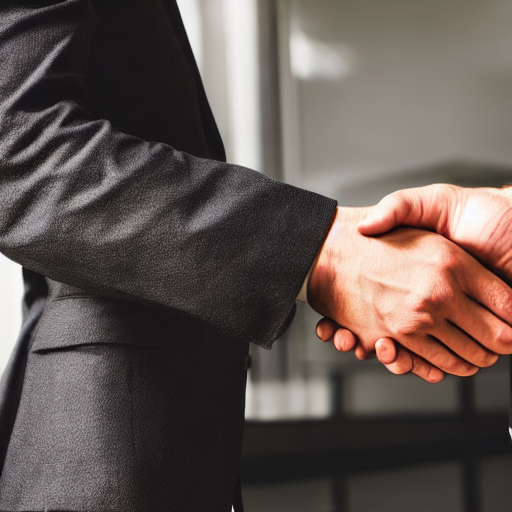

In [604]:
free()
pipe = pipe.to(pipe_device)
image_optimized_latent = pipe(
    prompt,
    latents=z_GT,
    num_inference_steps=20,
    guidance_scale=7.5,
    generator=generator).images[0]
image_optimized_latent

  0%|          | 0/20 [00:00<?, ?it/s]

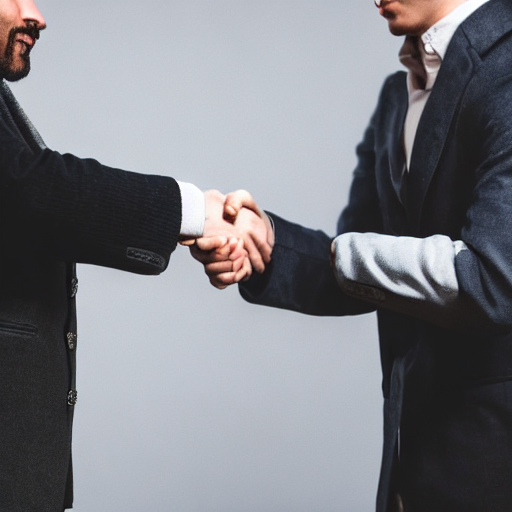

In [521]:
free()
pipe = pipe.to(pipe_device)
image_optimized_latent = pipe(
    prompt,
    latents=z_GT,
    num_inference_steps=20,
    guidance_scale=7.5,
    generator=generator).images[0]
image_optimized_latent

## TODO

- access vae [x]
- access initial distribution [x]
- access clip encoder [x]
- compute semantic loss [x]
- compute visual loss [x]
- optimize new latent [x]